<a href="https://colab.research.google.com/github/posummm/kmeans-dulux-color-clustering/blob/main/KMeans_Dulux.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import io
import os

# 2. Load Dataset

In [ ]:
print("1. LOAD DATASET")
from google.colab import files
print("Upload file CSV (dulux_dataset.csv):")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df[['R', 'G', 'B']] = df[['R', 'G', 'B']].astype(int)

print(f"Dataset berhasil dimuat! Total: {len(df)} warna.")
print(df.head()) # Menampilkan 5 data teratas

1. LOAD DATASET
Upload file CSV (dulux_dataset.csv):


Saving kdm - Sheet1.csv to kdm - Sheet1.csv
Dataset berhasil dimuat! Total: 144 warna.
   NO    R   G   B     KODE               NAMA
0   1  133  54  67  #853643     Wine Sensation
1   2  114  47  46  #722f2e     Intense Maroon
2   3  134  42  46  #862a2e    Crimson Sunbird
3   4  152  67  86  #984356  Radical Raspberry
4   5  153  40  44  #99282c            Rapture


# 3. Proses K-Means Clustering

In [ ]:
print("\n2. PROSES CLUSTERING")

k = 8

X = df[['R', 'G', 'B']].values

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)

df['Cluster'] = kmeans.labels_

print(f"Jumlah Cluster: {k}")
print(df['Cluster'].value_counts().sort_index())

for i in range(k):
    print(f"\nCluster {i} ({len(df[df['Cluster']==i])} warna):")
    print(df[df['Cluster']==i][['NAMA', 'KODE']].head(35).to_string(index=False))


2. PROSES CLUSTERING
Jumlah Cluster: 8
Cluster
0    35
1    16
2     9
3    18
4    16
5    14
6    23
7    13
Name: count, dtype: int64

Cluster 0 (35 warna):
              NAMA    KODE
    Fantastic Rose #ecb8be
       Cerise Feel #e6ced0
    Dollhouse Pink #f9cecd
  Beauty Behaviour #f6d6cf
        pink peach #f2d4c2
     caramel hint  #f6e0c9
 Portuguese Sonnet #e8cc8d
        May Yellow #f2dcaa
   Space Sensation #faebd1
     Celestial Sun #fbe5ad
      Boston Cream #f0e1bf
       Yellow Kiwi #f1e4b8
        Lime Twist #e8e5ae
        Juicy Pear #d5d6b5
       Meadow Mist #e6eacb
       Miami Grasa #bfd1a3
      French Green #bad9b8
    Victoria Green #bedac4
    Venetian Glass #d2e0bb
       Marine Glow #cce3c9
Grasshopper Spring #d0e4d2
         Lake Blue #acd6d8
        Musk Scene #cdd8cd
         Aqua Tint #c3e3df
    Summer Showers #c6e1e1
    Glistening Sea #b0d3db
     Denim Fantasy #c5e4e9
         Celestial #b1d2e6
         Blue Silk #c2d0df
      Winters Poet #c2c7d6
  

# 4. Visualisasi 3D Sebaran Warna


3. VISUALISASI 3D


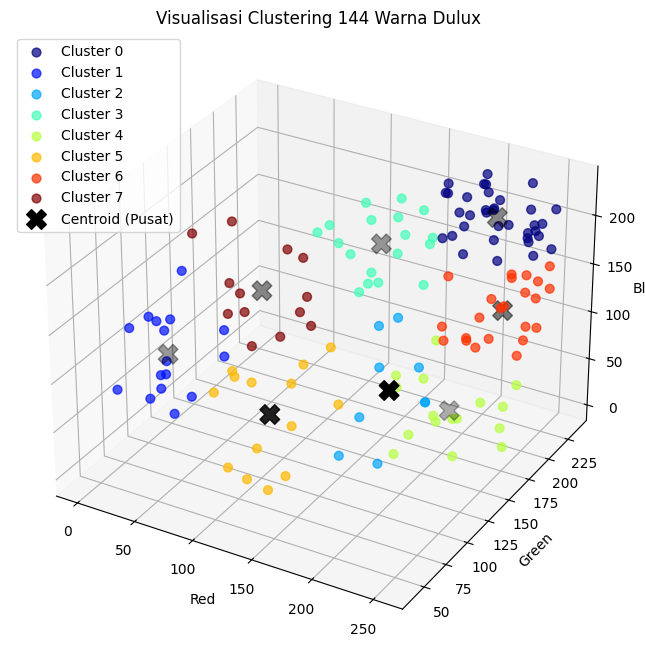

In [ ]:
print("\n3. VISUALISASI 3D")
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.jet(np.linspace(0, 1, k))
for i in range(k):
    cluster_data = df[df['Cluster'] == i]
    # plot titiknya
    ax.scatter(cluster_data['R'], cluster_data['G'], cluster_data['B'],
               label=f'Cluster {i}', s=40, alpha=0.7, c=[colors[i]])

centroids = kmeans.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
           c='black', marker='X', s=200, label='Centroid (Pusat)')

ax.set_xlabel('Red')
ax.set_ylabel('Green')
ax.set_zlabel('Blue')
plt.title(f'Visualisasi Clustering {len(df)} Warna Dulux')
plt.legend()
plt.show()

# 5. Testing dengan Foto Random


4. TESTING FOTO
Silakan upload Foto:


Saving WhatsApp Image 2026-05-19 at 12.55.33 AM.jpeg to WhatsApp Image 2026-05-19 at 12.55.33 AM (1).jpeg
Saving WhatsApp Image 2026-05-19 at 12.57.13 AM.jpeg to WhatsApp Image 2026-05-19 at 12.57.13 AM.jpeg
Saving WhatsApp Image 2026-05-19 at 12.59.04 AM.jpeg to WhatsApp Image 2026-05-19 at 12.59.04 AM.jpeg

--------------------------------------------------
Sedang memproses: WhatsApp Image 2026-05-19 at 12.55.33 AM (1).jpeg
Mean RGB     : R=76.2, G=159.6, B=226.2
Cluster      : 3
Rekomendasi  : Blue Moment
Kode         : #67a0c1
RGB Ref      : 103, 160, 193


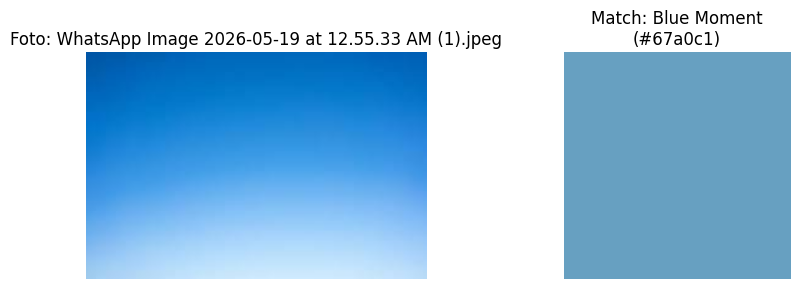


--------------------------------------------------
Sedang memproses: WhatsApp Image 2026-05-19 at 12.57.13 AM.jpeg
Mean RGB     : R=235.3, G=235.3, B=235.3
Cluster      : 0
Rekomendasi  : Portuguese Sonnet
Kode         : #e8cc8d
RGB Ref      : 232, 232, 232


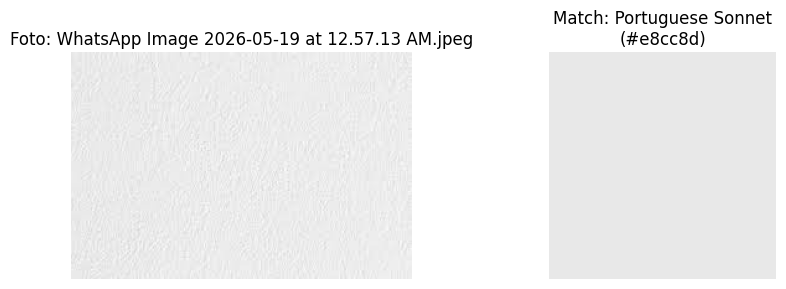


--------------------------------------------------
Sedang memproses: WhatsApp Image 2026-05-19 at 12.59.04 AM.jpeg
Mean RGB     : R=237.1, G=204.3, B=56.3
Cluster      : 4
Rekomendasi  : Sublime Solar
Kode         : #f9c13b
RGB Ref      : 249, 193, 59


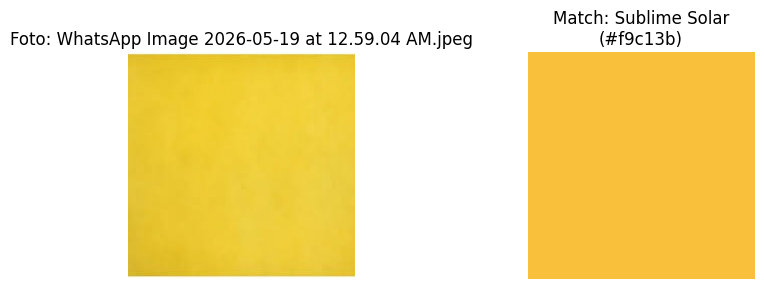


--------------------------------------------------
SEMUA FOTO TELAH DIPROSES!


In [ ]:
print("\n4. TESTING FOTO")
print("Silakan upload Foto:")
uploaded_test = files.upload()

for filename in uploaded_test.keys():

    print(f"\n--------------------------------------------------")
    print(f"Sedang memproses: {filename}")

    # Buka Gambar
    try:
        img = Image.open(filename).convert('RGB')
    except Exception as e:
        print(f"Error membuka file {filename}: {e}")
        continue

    img_small = img.resize((3, 3))
    img_array = np.array(img_small)
    mean_rgb = img_array.mean(axis=(0, 1))

    print(f"Mean RGB     : R={mean_rgb[0]:.1f}, G={mean_rgb[1]:.1f}, B={mean_rgb[2]:.1f}")

    # Prediksi Cluster
    cluster_pred = kmeans.predict([mean_rgb])[0]
    print(f"Cluster      : {cluster_pred}")

    # Cari Warna Dulux Paling Mendekati di dalam cluster tersebut
    cluster_members = df[df['Cluster'] == cluster_pred]
    member_rgb = cluster_members[['R', 'G', 'B']].values

    # Hitung jarak Euclidean
    distances = np.sqrt(np.sum((member_rgb - mean_rgb)**2, axis=1))
    closest_idx = distances.argmin()
    closest_color = cluster_members.iloc[closest_idx]

    print(f"Rekomendasi  : {closest_color['NAMA']}")
    print(f"Kode         : {closest_color['KODE']}")
    print(f"RGB Ref      : {closest_color['R']}, {closest_color['G']}, {closest_color['B']}")

    # Visualisasi Hasil (Per Foto)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

    # Foto Asli
    ax1.imshow(img)
    ax1.set_title(f"Foto: {filename}")
    ax1.axis('off')

    rgb_display = [closest_color['R']/255, closest_color['G']/255, closest_color['B']/255]
    ax2.imshow([[rgb_display]])
    ax2.set_title(f"Match: {closest_color['NAMA']}\n({closest_color['KODE']})")
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

print("\n--------------------------------------------------")
print("SEMUA FOTO TELAH DIPROSES!")